# 원본 노트북 링크:
- https://www.kaggle.com/code/vengadesaboopathi/offline-hmer-using-crohme-2019-dataset

In [1]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os

os.chdir('/content/drive/MyDrive/Colab Notebooks/프로젝트/2025 한양대 졸업프로젝트 HMER/OMRiDA 2')

In [3]:
import matplotlib.pyplot as plt

def plot_dataset(images, labels, grid_width, grid_height, figure_width, figure_height, y_hats=None, vocab=None, wspace=0.5, hspace=1):

  # images, labels는 torch.tensor 타입으로 들어온다고 가정

  f, ax = plt.subplots(grid_height, grid_width, squeeze=False)
  f.set_size_inches(figure_width, figure_height)
  img_idx = 0

  eos_idx = 1

  for i in range(0, grid_height):
    for j in range(0, grid_width):
      image = images[img_idx].cpu().detach()
      label = labels[img_idx].cpu().detach()
      title_color = 'k'

      assert vocab is not None, "vocab을 입력하세요"

      label = label.tolist()
      label = label[1:label.index(eos_idx)]     # <sos>, <eos> 부분 제외 (EOS_IDX == 2) - <eos> 이전까지 뽑아서 <eos>이후 <pad> 부분도 제외되도록
      label = vocab.decode(label)               # list -> str

      if y_hats is not None:
            y_hat = y_hats[img_idx].cpu().detach().tolist()

            if eos_idx in y_hat:
                y_hat = y_hat[:y_hat.index(eos_idx)]   # <eos> 존재하면 <eos> 이후부분 (<eos> 및 <pad>) 무시

            y_hat = vocab.decode(y_hat)         # list -> str


            if label != y_hat:
                title_color = 'r'

            label = f'gt: {label}\npred:{y_hat}'

      ax[i][j].axis('off')
      ax[i][j].set_title(label, color=title_color)
      ax[i][j].imshow(image.permute(1,2,0).numpy(), aspect='auto', cmap='gray')
      img_idx += 1

    plt.subplots_adjust(left=0, bottom=0, right=2, top=2, wspace=wspace, hspace=hspace)
  plt.show()

In [4]:
import editdistance

def exprate_k(preds, targets, k=0, eos_idx=1):

    # preds, targets에는 <sos>가 제거된 채로 함수인자로 들어온다고 가정

    # preds: (B, T-1)
    # targets: (B, T-1)

    assert preds.shape[0] == targets.shape[0], "예측 label과 정답 label의 배치 크기가 다릅니다"

    cnt = 0
    for pred_seq, tgt_seq in zip(preds, targets):

        pred = pred_seq.tolist()
        tgt = tgt_seq.tolist()

        if eos_idx in pred:
            pred = pred[:pred.index(eos_idx)]

        if eos_idx in tgt:
            tgt = tgt[:tgt.index(eos_idx)]

        diff = editdistance.eval(pred, tgt)

        if diff<=k:
            cnt += 1

    return cnt / preds.shape[0]


def WER(preds, targets, eos_idx=1):

    # preds, targets에는 <sos>가 제거된 채로 함수인자로 들어온다고 가정

    # preds: (B, T-1)
    # targets: (B, T-1)

    assert preds.shape[0] == targets.shape[0], "예측 label과 정답 label의 배치 크기가 다릅니다"

    sum_wer = 0.0
    for pred_seq, tgt_seq in zip(preds, targets):

        pred = pred_seq.tolist()
        tgt = tgt_seq.tolist()

        if eos_idx in pred:
            pred = pred[:pred.index(eos_idx)]

        if eos_idx in tgt:
            tgt = tgt[:tgt.index(eos_idx)]

        distance = editdistance.eval(pred, tgt)
        length = len(tgt)

        sum_wer += (distance/length)

    return sum_wer / preds.shape[0]

In [5]:
import os
import json
from pathlib import Path

def save_log(log_dict, save_path="log.json"):

    Path(save_path).parent.mkdir(parents=True, exist_ok=True)
    with open(save_path, "w", encoding="utf-8") as f:
        json.dump(log_dict, f, indent=2)
    print(f"저장 완료: {save_path}")


def plot_loss_curve(log_dict, metric="loss", overlap=False):

    assert metric in ["loss", "expr@0", "expr@1", "expr@2", "expr@3", "wer"], "metric은 loss, expr@0, expr@2, expr@3, wer 중 선택하여 입력해야합니다"

    if overlap==False:
        fig, axes = plt.subplots(2,1)

        fig.suptitle(f"{metric} Curve")

        # train
        train = log_dict["Train"]
        epochs = range(1, len(train)+1)

        train_metric = []
        for log in train:
            train_metric.append(log[metric])

        axes[0].plot(epochs, train_metric, marker='o')
        axes[0].set_xlabel("Epoch")
        axes[0].set_ylabel(f"train {metric}")
        axes[0].grid(True)


        # valid
        valid = log_dict["Valid"]
        epochs = range(1, len(valid)+1)

        valid_metric = []
        for log in valid:
            valid_metric.append(log[metric])

        axes[1].plot(epochs, valid_metric, marker='o')
        axes[1].set_xlabel("Epoch")
        axes[1].set_ylabel(f"valid {metric}")
        axes[1].grid(True)

        plt.tight_layout()
        plt.show()

    else:

        # train
        train = log_dict["Train"]
        epochs = range(1, len(train)+1)

        train_metric = []
        for log in train:
            train_metric.append(log[metric])

        plt.plot(epochs, train_metric, marker='o', label=f"Train {metric}")


        # valid
        valid = log_dict["Valid"]
        epochs = range(1, len(valid)+1)

        valid_metric = []
        for log in valid:
            valid_metric.append(log[metric])

        plt.plot(epochs, valid_metric, marker='o', label=f"Valid {metric}")

        plt.xlabel("Epoch")
        plt.ylabel(f"{metric}")
        plt.title(f"{metric} Curve")

        plt.legend()
        plt.grid(True)
        plt.show()

In [6]:
import gspread

def save_test_result(experiment_name, val_dict):
    """ 실험결과를 구글스프레드시트에 저장 """

    gc = gspread.service_account(filename="service_account.json")
    sh = gc.open("test_results")

    # experiment_name이 스프레드시트의 각 sheet (윈도우)에 존재하는지 확인
    for metric in ["loss", "expr@0", "expr@1", "expr@2", "expr@3", "wer"]:
        worksheet = sh.worksheet(metric)

        try:
            row = worksheet.find(experiment_name).row

            # 이미 해당 실험이 과거에 진행된 경우가 있어 값들이 채워져있다면, 새로 실험하는 것이므로 해당 실험의 이전값들을 모든 sheet (윈도우)에 대해서 초기화해주고 시작
            range = f"B{row}:I{row}"
            val = [[""] * 8]
            worksheet.batch_update([{
                "range": range,
                "values": val
            }])

        except:
            last_row = len(worksheet.col_values(1))  # A열 중 값이 채워진 부분의 마지막 행번호
            worksheet.update_cell(last_row+1, 1, experiment_name)

    for metric in val_dict.keys():
        worksheet = sh.worksheet(metric)
        row = worksheet.find(experiment_name).row

        range = f"B{row}:I{row}"
        worksheet.batch_update([{
            "range": range,
            "values": [val_dict[metric]]
        }])

# Config (Global Parameters)

In [7]:
import torch
DEVICE = "cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu"

In [8]:
import os, json
import torch

CFG = {
  "img_size": (128,768),
  "pad_idx": 112,
  "eos_idx": 1,

  "data": {
    "crohme": {
      "hme_img": "data/preprocessed/train/paired/crohme/hme_preprocessed",
      "pme_img": "data/preprocessed/train/paired/crohme/pme_preprocessed",
      "caption": "data/preprocessed/train/paired/crohme/caption.txt",
    },
    "im2latex": {
      "hme_img": "data/preprocessed/train/paired/im2latex/hme_img_train",
      "pme_img": "data/preprocessed/train/paired/im2latex/pme_img_train",
      "caption": "data/preprocessed/train/paired/im2latex/caption_train.txt",
    },
  },

  "model": {
    "vocab_size": 112,
    "encoder_emb_dim": 256,
    "decoder_emb_dim": 256,
    "decoder_hidden_dim": 512
  },

  "training": {
    "batch_size": 1,
    "epochs": 20,
    "learning_rate": 1e-4,   # 사실상 CosineAnnealingWarmupRestarts사용하면 이 부분의 학습률은 적용 안되는 셈임
    "match_weight": 0.2,      # DWAP에는 사용되지 않는 파라미터
    "optimizer": "adadelta",
    "weight_decay": 1e-4,
    "grad_clip": 1.0,
    "tf_ratio": 0.5
  },

  "testing": {"max_len": 150}
}

num_steps_in_epoch = (8834*0.8)//CFG["training"]["batch_size"]
epochs = CFG["training"]["epochs"]

scheduler_info = {"name": None}

# params_cosineAnnealingWarmupRestarts = {"first_cycle_steps": num_steps_in_epoch * epochs,  # 전체 에포크가 한 사이클
#                                         "cycle_mult": 1.0,
#                                         "max_lr": 0.1,
#                                         "min_lr": 5e-4,
#                                         "warmup_steps": num_steps_in_epoch * 0.1 * epochs,  # 전체 에포크의 10%를 warmup에 사용
#                                         "gamma": 1.0
#                                         }
# scheduler_info["params"] = params_cosineAnnealingWarmupRestarts

CFG["training"]["early_stop_patience"] = max(2, int(epochs*0.04))


experiment_name = f"Graph-Transformer based (Kaggle baseline)_epoch{epochs}_bs{CFG['training']['batch_size']}_scheduler_None_patience_{CFG['training']['early_stop_patience']}"

CFG["experiment_name"] = experiment_name

paths = {}
paths["best_ckpt"] = f"runs/{experiment_name}/best_model.pth"
paths["last_ckpt"] = f"runs/{experiment_name}/last_model.pth"
paths["train_log_json"] = f"runs/{experiment_name}/train_log.json"
paths["CFG"] = f"runs/{experiment_name}/config.json"

CFG["paths"] = paths

CFG["scheduler"] = scheduler_info

In [9]:
# 실험환경 디테일 config 저장

save_log(CFG, CFG["paths"]["CFG"])

저장 완료: runs/Graph-Transformer based (Kaggle baseline)_epoch20_bs1_scheduler_None_patience_2/config.json


In [10]:
# 실험환경 폴더 생성

Path(os.path.join("runs", CFG["experiment_name"])).mkdir(parents=True, exist_ok=True)

# Custom Dataset

## Vocab

In [11]:
# IM2LATEX 캡션 전처리용
def tokenize_formula(formula):
    ans = []
    tokens = formula.strip().split()

    for tok in tokens:
        chk = 0
        for sym in ["cm", "mm", "pt", "in", "ex", "em"]:
            if (tok[-2:] == sym) and tok[-3].isdigit():
                num, _ = tok.split(sym)
                num = ' '.join(num).split()
                ans.extend(num)
                ans.append(sym)
                chk = 1
                break

        if chk == 0:
            ans.append(tok)
    return ans


from typing import List

class Vocab:
  SOS_TOKEN = "<sos>"
  EOS_TOKEN = "<eos>"

  def __init__(self):
    self.default_tokens = [self.SOS_TOKEN, self.EOS_TOKEN]
    self.token2idx = {tok: idx for idx, tok in enumerate(self.default_tokens)}
    self.idx2token = self.default_tokens.copy()

  def __len__(self):
    return len(self.idx2token)

  def load_from_txt(self, path):
    with open(path, "r", encoding="latin1") as f:
      for line in f:
        token = line.strip()
        if token not in self.token2idx:
          idx = len(self.token2idx)
          self.token2idx[token] = idx
          self.idx2token.append(token)

  def encode(self, caption: str) -> List[int]:
    tokens = tokenize_formula(caption)
    return [self.token2idx[self.SOS_TOKEN]] + \
           [self.token2idx[token] for token in tokens] + \
           [self.token2idx[self.EOS_TOKEN]]

  def decode(self, token_ids: List[int]) -> str:
    return ' '.join([self.idx2token[token_id] for token_id in token_ids])

vocab = Vocab()
vocab.load_from_txt("vocab.txt")

In [12]:
from torchvision import transforms
import torch
from PIL import ImageOps

def formula_collate_fn(batch):
    images = torch.stack([item["image"] for item in batch], dim=0)
    formulas = torch.nn.utils.rnn.pad_sequence(
        [item["formula"] for item in batch],
        batch_first=True,
        padding_value=CFG["pad_idx"]
    )
    return {"image": images, "formula": formulas}

In [13]:
sym2idx = vocab.token2idx
group2sym = vocab.idx2token

In [14]:
from pathlib import Path
from torch.utils.data import Dataset
from PIL import Image
import torch


transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Resize(CFG["img_size"]),
    transforms.Normalize(mean=[0.5], std=[0.5]),]
)


class FormulaDataset(Dataset):
  def __init__(self, img_path, labels_path, transform, vocab):
    self.img_path = img_path
    self.labels_path = labels_path
    self.transform = transform
    self.vocab = vocab

    self.samples = []
    with open(labels_path, "r", encoding="utf-8") as f:
      for line in f:
        parts = line.strip().split('\t')
        if len(parts)!=2:
          continue
        file_id, caption = parts

        if '.' not in file_id:
          file_id = f"{file_id}.png"

        img_path = os.path.join(self.img_path, file_id)
        if os.path.exists(img_path):
          self.samples.append((img_path, caption))

  def __len__(self):
    return len(self.samples)

  def __getitem__(self, idx):
    img_path, caption = self.samples[idx]
    img = Image.open(img_path).convert('L')

    if self.transform:
      img = self.transform(img)

    caption_tokens = self.vocab.encode(caption)
    caption = torch.tensor(caption_tokens)

    return {"image": img, "formula": caption}

In [15]:
train_path = CFG["data"]["crohme"]["hme_img"]
train_labels_path = CFG["data"]["crohme"]["caption"]

years = [2014, 2016, 2019]
crohme_test_paths = [f"data/preprocessed/test/hme/crohme/{year}/hme_img_preprocessed" for year in years]
crohme_test_labels_paths = [f"data/preprocessed/test/hme/crohme/{year}/caption.txt" for year in years]

cropme_test_paths = [f"data/preprocessed/test/pme/crohme/{year}/pme_img" for year in years]
cropme_test_labels_paths = [f"data/preprocessed/test/pme/crohme/{year}/caption.txt" for year in years]

im2latex_pme_path = "data/preprocessed/test/pme/im2latex/pme_img_test"
im2latex_pme_labels_path = "data/preprocessed/test/pme/im2latex/caption_test.txt"

im2latex_hme_path = "data/preprocessed/test/hme/im2latex/hme_img_test"
im2latex_hme_labels_path = "data/preprocessed/test/hme/im2latex/caption_test.txt"

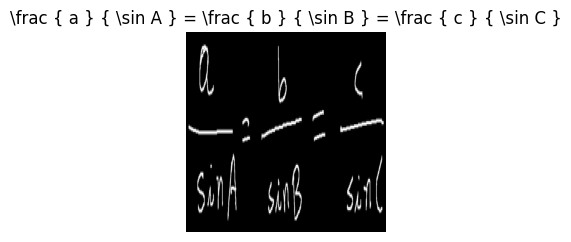

In [16]:
batch_size = CFG["training"]["batch_size"]


# train valid split
trainset = FormulaDataset(train_path, train_labels_path, transform, vocab)
train_size = int(0.8 * len(trainset))
valid_size = len(trainset) - train_size
trainset, validset = torch.utils.data.random_split(trainset,[train_size, valid_size])


# loader

# train, valid
trainloader = torch.utils.data.DataLoader(
    trainset, batch_size=batch_size, shuffle=True, collate_fn=formula_collate_fn
)
validloader = torch.utils.data.DataLoader(
    validset, batch_size=1, shuffle=False, collate_fn=formula_collate_fn
)

# test - CROHME
crohme_testset_2014 = FormulaDataset(crohme_test_paths[0], crohme_test_labels_paths[0], transform, vocab)
crohme_testset_2016 = FormulaDataset(crohme_test_paths[1], crohme_test_labels_paths[1], transform, vocab)
crohme_testset_2019 = FormulaDataset(crohme_test_paths[2], crohme_test_labels_paths[2], transform, vocab)

crohme_testloader_2014 = torch.utils.data.DataLoader(
    crohme_testset_2014, batch_size=1, shuffle=False, collate_fn=formula_collate_fn,
    num_workers=2, pin_memory=True, persistent_workers=True, prefetch_factor=2
)

crohme_testloader_2016 = torch.utils.data.DataLoader(
    crohme_testset_2016, batch_size=1, shuffle=False, collate_fn=formula_collate_fn,
    num_workers=2, pin_memory=True, persistent_workers=True, prefetch_factor=2
)

crohme_testloader_2019 = torch.utils.data.DataLoader(
    crohme_testset_2019, batch_size=1, shuffle=False, collate_fn=formula_collate_fn,
    num_workers=2, pin_memory=True, persistent_workers=True, prefetch_factor=2
)

# test - CROPME
cropme_testset_2014 = FormulaDataset(cropme_test_paths[0], cropme_test_labels_paths[0], transform, vocab)
cropme_testset_2016 = FormulaDataset(cropme_test_paths[1], cropme_test_labels_paths[1], transform, vocab)
cropme_testset_2019 = FormulaDataset(cropme_test_paths[2], cropme_test_labels_paths[2], transform, vocab)

cropme_testloader_2014 = torch.utils.data.DataLoader(
    cropme_testset_2014, batch_size=1, shuffle=False, collate_fn=formula_collate_fn,
    num_workers=2, pin_memory=True, persistent_workers=True, prefetch_factor=2
)

cropme_testloader_2016 = torch.utils.data.DataLoader(
    cropme_testset_2016, batch_size=1, shuffle=False, collate_fn=formula_collate_fn,
    num_workers=2, pin_memory=True, persistent_workers=True, prefetch_factor=2
)

cropme_testloader_2019 = torch.utils.data.DataLoader(
    cropme_testset_2019, batch_size=1, shuffle=False, collate_fn=formula_collate_fn,
    num_workers=2, pin_memory=True, persistent_workers=True, prefetch_factor=2
)


# test - IM2LATEX (vocab 통일한 IM2LATEX의 caption 중 7:3으로 훈련 테스트 데이터 나누어 별도로 저장하여 구성하였음)

im2latex_hme_testset = FormulaDataset(im2latex_hme_path, im2latex_hme_labels_path, transform, vocab)
im2latex_hme_testloader = torch.utils.data.DataLoader(
    im2latex_hme_testset, batch_size=1, shuffle=False, collate_fn=formula_collate_fn,
    num_workers=2, pin_memory=True, persistent_workers=True, prefetch_factor=2
)

im2latex_pme_testset = FormulaDataset(im2latex_pme_path, im2latex_pme_labels_path, transform, vocab)
im2latex_pme_testloader = torch.utils.data.DataLoader(
    im2latex_pme_testset, batch_size=1, shuffle=False, collate_fn=formula_collate_fn,
    num_workers=2, pin_memory=True, persistent_workers=True, prefetch_factor=2
)


# 데이터 확인

batch = next(iter(trainloader))
images = batch['image']
labels = batch['formula']
plot_dataset(images, labels, grid_width=1, grid_height=1, figure_width=1, figure_height=1, vocab=vocab, wspace=0.25, hspace=0.25)

# MODEL

In [17]:
!pip install torch_geometric

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.1/63.1 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 76.3 MB/s eta 0:00:00


In [18]:
import torch
import torch.nn as nn
from torch_geometric.nn import GATConv

class ContrastiveRegionProposal(nn.Module):
    def __init__(self, feat_dim=256, emb_dim=128, patch_size=16):
        super().__init__()
        self.patch_size = patch_size
        self.projection = nn.Sequential(
            nn.Linear(feat_dim * patch_size**2, 256),
            nn.ReLU(),
            nn.Linear(256, emb_dim)
        )

    def extract_patches(self, x):
        # x: [B, C, H, W] → [B, num_patches, C*patch_size²]
        B, C, H, W = x.shape
        patches = x.unfold(2, self.patch_size, 8).unfold(3, self.patch_size, 8)
        patches = patches.contiguous().view(B, -1, C * self.patch_size**2)
        return patches

    def forward(self, x):
        patches = self.extract_patches(x)  # [B, N, C*patch_size²]
        return self.projection(patches)  # [B, N, emb_dim]

In [19]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import models as tv_models
from torch_geometric.nn import GATConv

# --- Positional Encoding for the Transformer ---
class PositionalEncoding(nn.Module):
    def __init__(self, d_model: int, max_len: int = 5000):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len).unsqueeze(1).float()
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * -(math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0)
        self.register_buffer('pe', pe)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x: [B, seq_len, d_model]
        seq_len = x.size(1)
        return x + self.pe[:, :seq_len]

# --- Transformer Decoder Module adapted for graph memory ---
class TransformerDecoderHead(nn.Module):
    def __init__(self, vocab_size: int, emb_dim: int = 256,
                 d_model: int = 256,
                 n_layers: int = 4, n_heads: int = 4,
                 ff_dim: int = 512, dropout: float = 0.1):

        super().__init__()
        # Embedding layer for target tokens
        self.sos_idx = 0
        self.eos_idx = 1
        self.emb = nn.Embedding(vocab_size, emb_dim)
        self.pos_enc = PositionalEncoding(emb_dim)

        decoder_layer = nn.TransformerDecoderLayer(
            d_model=emb_dim, nhead=n_heads,
            dim_feedforward=ff_dim, dropout=dropout
        )
        self.transformer_decoder = nn.TransformerDecoder(decoder_layer, num_layers=n_layers)

        # Project memory features from encoder to embedding dimension
        self.memory_proj = nn.Linear(d_model, emb_dim)

        # Final linear layer to predict vocabulary logits
        self.output_proj = nn.Linear(emb_dim, vocab_size)

        self.emb_dim = emb_dim

    def forward(self, memory: torch.Tensor, tgt_ids: torch.LongTensor) -> torch.Tensor:
        # memory: [S, B, emb_dim]
        B, T = tgt_ids.size()
        # target embeddings
        tgt_emb = self.emb(tgt_ids)            # [B, T, emb_dim]
        tgt_emb = self.pos_enc(tgt_emb)        # [B, T, emb_dim]
        tgt_emb = tgt_emb.permute(1, 0, 2)     # [T, B, emb_dim]
        tgt_mask = nn.Transformer.generate_square_subsequent_mask(T).to(tgt_ids.device)
        dec_out = self.transformer_decoder(
            tgt=tgt_emb, memory=memory, tgt_mask=tgt_mask
        )                                      # [T, B, emb_dim]
        dec_out = dec_out.permute(1, 0, 2)     # [B, T, emb_dim]

        logits = self.output_proj(dec_out)     # [B, T, vocab] (eos 포함)

        return logits

# --- Full HMER Network with Graph-based memory ---
# --- Revised GNN Components ---
class GATEncoder(nn.Module):
    def __init__(self, in_dim, hidden_dim=128, heads=4):
        super().__init__()
        # First GAT layer: increase output dimension to match transformer
        self.gat1 = GATConv(in_dim, hidden_dim, heads=heads)
        # Second GAT layer: maintain dimension compatibility
        self.gat2 = GATConv(hidden_dim*heads, hidden_dim, heads=1)

    def forward(self, x, edge_index):
        x = F.relu(self.gat1(x, edge_index))  # [N, hidden_dim*heads]
        return self.gat2(x, edge_index)       # [N, hidden_dim]

# --- Modified HMER Network ---
class HMERNet(nn.Module):
    def __init__(self, input_channels: int, feat_dim: int, vocab_size: int,
                 emb_dim: int = 256, region_emb_dim: int = 128):
        super().__init__()
        # 1. CNN Encoder
        resnet = tv_models.resnet18(weights=None)
        resnet.conv1 = nn.Conv2d(input_channels, 64, 3, 1, 1, bias=False)
        resnet.maxpool = nn.Identity()
        self.encoder = nn.Sequential(*list(resnet.children())[:-2])
        self.proj = nn.Conv2d(512, feat_dim, kernel_size=1)

        # 2. Region Proposal
        self.region_proposal = ContrastiveRegionProposal(
            feat_dim=feat_dim, emb_dim=region_emb_dim
        )

        # 3. GNN Components
        self.gnn = GATEncoder(in_dim=region_emb_dim, hidden_dim=emb_dim)
        self.gnn_proj = nn.Linear(emb_dim, emb_dim)

        # 4. Transformer Decoder
        self.decoder = TransformerDecoderHead(
            vocab_size=vocab_size,
            emb_dim=emb_dim,
            d_model=emb_dim
        )

    def build_graph(self, centers: torch.Tensor) -> torch.Tensor:
        # Robust edge construction with fallback
        K = centers.size(0)
        edge_list = []

        # Mandatory self-loops
        edge_list.extend([[i, i] for i in range(K)])

        # Adaptive neighbor connections
        if K > 1:
            cos_sim = F.cosine_similarity(
                centers.unsqueeze(1), centers.unsqueeze(0), dim=-1
            )
            for i in range(K):
                # Connect to top-2 similar nodes (excluding self)
                _, indices = torch.topk(cos_sim[i], k=3)
                for j in indices[1:3]:  # Skip self (index 0)
                    edge_list.extend([[i, j.item()], [j.item(), i]])

        return torch.tensor(edge_list, dtype=torch.long,
                          device=centers.device).t().contiguous()

    def forward(self, x: torch.Tensor, tgt_ids: torch.LongTensor):
        # 1. Feature extraction
        feat_map = self.proj(self.encoder(x))  # [B, feat_dim, H, W]

        # 2. Region proposals
        region_emb = self.region_proposal(feat_map)  # [B, N, region_emb_dim]

        # 3. GNN processing
        centers = region_emb.squeeze(0)  # [N, region_emb_dim]
        edge_index = self.build_graph(centers)
        gnn_out = self.gnn(centers, edge_index)  # [N, emb_dim]

        # 4. Prepare memory (CRITICAL FIX)
        memory = gnn_out.unsqueeze(1)  # [N, 1, emb_dim] (seq_len, batch, features)

        # 5. Decoding
        logits = self.decoder(memory, tgt_ids)
        return logits

    def generate(self, feats: torch.Tensor, max_len: int = 100) -> torch.Tensor:
        """Autoregressive greedy decoding for inference"""
        self.eval()
        B = feats.size(0)

        # Initialize with <SOS> token
        input_ids = torch.full((B, 1), 0,  # <SOS> index
                             dtype=torch.long, device=feats.device)

        # Prepare memory (same as forward pass)
        with torch.no_grad():
            feat_map = self.proj(self.encoder(feats))
            region_emb = self.region_proposal(feat_map)
            centers = region_emb.squeeze(0)
            edge_index = self.build_graph(centers)
            gnn_out = self.gnn(centers, edge_index)
            memory = gnn_out.unsqueeze(1)  # [N, 1, emb_dim]

        # Autoregressive decoding
        for _ in range(max_len-1):  # -1 because we start with SOS
            logits = self.decoder(memory, input_ids)  # [B, curr_len, vocab]

            # Greedy next token
            next_id = logits[:, -1, :].argmax(dim=-1, keepdim=True)
            input_ids = torch.cat([input_ids, next_id], dim=-1)

            # Stop if all sequences predicted <EOS>
            if (next_id == 1).all():  # <EOS> index
                break

        return input_ids[:, 1:]  # <sos> 제외, <eos> 포함

# Train

In [23]:
def train(model, train_loader, valid_loader=None, criterion=None, optimizer=None, scheduler=None, device="cuda"):

    EPOCHS = CFG["training"]["epochs"]
    GRAD_CLIP = CFG["training"]["grad_clip"]
    eos_idx = CFG["eos_idx"]

    best_loss = float("inf")
    patience = 0

    log_dict = {"Train": [], "Valid": []}

    save_best = Path(CFG["paths"]["best_ckpt"])
    save_last = Path(CFG["paths"]["last_ckpt"])

    try:
        for epoch in range(1, EPOCHS+1):
            model.train()
            total_loss = 0.0
            total_expr_0, total_expr_1, total_expr_2, total_expr_3 = 0.0, 0.0, 0.0, 0.0
            total_wer = 0.0
            num_batches = 0
            lr_history = []

            loop = tqdm(train_loader, desc=f"[Train] Epoch {epoch}/{EPOCHS}", leave=True)

            for batch in loop:
                optimizer.zero_grad()

                imgs = batch["image"].to(device)
                labels = batch["formula"].to(device)

                pred = model(imgs, labels[:, :-1])      # (B,T-1,V) - 트랜스포머 구조이므로 정답 라벨에서 <eos> 제외한 부분만이 tgt_ids로 들어가야함
                labels = labels[:, 1:]                  # sos부분은 제외: (B,T) => (B,T-1)

                loss = criterion(pred.transpose(1,2), labels)  # nn.CrossEntropyLoss() input shape 규칙에 따라 (B,V,T-2)로 pred가 와야하므로 맞춰줌
                pred_tokens = pred.argmax(dim=-1)       # (B,T-1,V) -> (B,T-1)

                loss.backward()

                if GRAD_CLIP and GRAD_CLIP > 0:
                    torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)

                optimizer.step()

                with torch.no_grad():
                    expr_0 = exprate_k(preds=pred_tokens, targets=labels, k=0, eos_idx=eos_idx)
                    expr_1 = exprate_k(preds=pred_tokens, targets=labels, k=1, eos_idx=eos_idx)
                    expr_2 = exprate_k(preds=pred_tokens, targets=labels, k=2, eos_idx=eos_idx)
                    expr_3 = exprate_k(preds=pred_tokens, targets=labels, k=3, eos_idx=eos_idx)
                    wer = WER(preds=pred_tokens, targets=labels, eos_idx=eos_idx)

                total_loss += float(loss.item())
                total_expr_0 += float(expr_0)
                total_expr_1 += float(expr_1)
                total_expr_2 += float(expr_2)
                total_expr_3 += float(expr_3)
                total_wer += float(wer)
                num_batches += 1

                loop.set_postfix(loss=loss.item(), expr0=expr_0, expr1=expr_1, expr2=expr_2, expr3=expr_3, wer=wer, lr=optimizer.param_groups[0]['lr'])

                if scheduler is not None:
                    scheduler.step()

                lr_history.append(optimizer.param_groups[0]['lr'])

            avg_loss = total_loss / num_batches
            avg_expr_0 = total_expr_0 / num_batches
            avg_expr_1 = total_expr_1 / num_batches
            avg_expr_2 = total_expr_2 / num_batches
            avg_expr_3 = total_expr_3 / num_batches
            avg_wer = total_wer / num_batches


            print(f"\n[Train Epoch {epoch}] Loss: {avg_loss:.4f}, "
                f"Expr@0: {avg_expr_0:.4f}, Expr@1: {avg_expr_1:.4f}, Expr@2: {avg_expr_2:.4f}, Expr@3: {avg_expr_3:.4f}, WER: {avg_wer:.4f}")

            log_dict["Train"].append({
                "epoch": epoch,
                "loss": avg_loss,
                "expr@0": avg_expr_0,
                "expr@1": avg_expr_1,
                "expr@2": avg_expr_2,
                "expr@3": avg_expr_3,
                "wer": avg_wer,
                "lr": lr_history
            })

            # 에포크 끝날때마다 스케줄려 업데이트 하는 경우
            # if scheduler:
            #     if isinstance(scheduler, torch.optim.lr_scheduler.ReduceLROnPlateau):
            #         scheduler.step(avg_loss)
            #     else:
            #         scheduler.step()



            # validation
            model.eval()
            total_loss = 0.0
            total_expr_0, total_expr_1, total_expr_2, total_expr_3 = 0.0, 0.0, 0.0, 0.0
            total_wer = 0.0
            num_batches = 0

            loop = tqdm(valid_loader, desc=f"[Valid] Epoch {epoch}/{EPOCHS}", leave=True)

            for batch in loop:

                imgs = batch["image"].to(device)
                labels = batch["formula"].to(device)

                pred = model(imgs, labels[:, :-1])      # (B,T-1,V) - 트랜스포머 구조이므로 정답 라벨에서 <eos> 제외한 부분만이 tgt_ids로 들어가야함
                labels = labels[:, 1:]                  # sos부분은 제외: (B,T) => (B,T-1)

                loss = criterion(pred.transpose(1,2), labels)  # nn.CrossEntropyLoss() input shape 규칙에 따라 (B,V,T-2)로 pred가 와야하므로 맞춰줌
                pred_tokens = pred.argmax(dim=-1)       # (B,T-1,V) -> (B,T-1)

                expr_0 = float(exprate_k(preds=pred_tokens, targets=labels, k=0, eos_idx=eos_idx))
                expr_1 = float(exprate_k(preds=pred_tokens, targets=labels, k=1, eos_idx=eos_idx))
                expr_2 = float(exprate_k(preds=pred_tokens, targets=labels, k=2, eos_idx=eos_idx))
                expr_3 = float(exprate_k(preds=pred_tokens, targets=labels, k=3, eos_idx=eos_idx))
                wer = float(WER(preds=pred_tokens, targets=labels, eos_idx=eos_idx))

                total_loss += float(loss.item())
                total_expr_0 += expr_0
                total_expr_1 += expr_1
                total_expr_2 += expr_2
                total_expr_3 += expr_3
                total_wer += wer
                num_batches += 1

                loop.set_postfix(loss=loss.item(), expr0=expr_0, expr1=expr_1, expr2=expr_2, expr3=expr_3, wer=wer)

            avg_loss = total_loss / num_batches
            avg_expr_0 = total_expr_0 / num_batches
            avg_expr_1 = total_expr_1 / num_batches
            avg_expr_2 = total_expr_2 / num_batches
            avg_expr_3 = total_expr_3 / num_batches
            avg_wer = total_wer / num_batches


            print(f"\n[Valid Epoch {epoch}] Loss: {avg_loss:.4f}, "
                f"Expr@0: {avg_expr_0:.4f}, Expr@1: {avg_expr_1:.4f}, Expr@2: {avg_expr_2:.4f}, Expr@3: {avg_expr_3:.4f}, WER: {avg_wer:.4f}")

            log_dict["Valid"].append({
                "epoch": epoch,
                "loss": avg_loss,
                "expr@0": avg_expr_0,
                "expr@1": avg_expr_1,
                "expr@2": avg_expr_2,
                "expr@3": avg_expr_3,
                "wer": avg_wer
            })

            torch.save({"model": model.state_dict()}, save_last)

            if epoch == 1 or avg_loss < best_loss:
                best_loss = avg_loss
                patience = 0
                save_best.parent.mkdir(parents=True, exist_ok=True)
                torch.save({"model": model.state_dict()}, save_best)
                print("Best model saved.")

            else:
                patience += 1
                print(f"Early Stopping count: {patience}/{CFG['training']['early_stop_patience']}")
                if patience >= CFG["training"]["early_stop_patience"]:
                    print(f"Early stopping at epoch {epoch}")
                    break

            print()

    except KeyboardInterrupt:
        print("\n Training interrupted by user. Returning current results...")
        torch.save({"model": model.state_dict()}, save_last)  # 현재 상태 저장

    finally:
        return log_dict, best_loss

In [24]:
import math
from tqdm import tqdm

VOCAB_SIZE = CFG["model"]["vocab_size"]
FEAT_DIM   = CFG["model"]["decoder_hidden_dim"]
EMB_DIM    = CFG["model"]["encoder_emb_dim"]
EPOCHS     = CFG["training"]["epochs"]
BATCH_SIZE = CFG["training"]["batch_size"]
PAD_IDX    = CFG["pad_idx"]


model = HMERNet(1, FEAT_DIM, VOCAB_SIZE, EMB_DIM).to(DEVICE)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4)
criterion = nn.CrossEntropyLoss(ignore_index=PAD_IDX)


# Train loop
log_dict, best_loss = train(model, trainloader, validloader, criterion=criterion, optimizer=optimizer, scheduler=None, device=DEVICE)

[Train] Epoch 1/20: 100%|██████████| 7067/7067 [1:33:52<00:00,  1.25it/s, expr0=0, expr1=0, expr2=0, expr3=0, loss=0.809, lr=0.0001, wer=0.229]



[Train Epoch 1] Loss: 2.2224, Expr@0: 0.0024, Expr@1: 0.0693, Expr@2: 0.1336, Expr@3: 0.2292, WER: 0.6593


[Valid] Epoch 1/20: 100%|██████████| 1767/1767 [22:56<00:00,  1.28it/s, expr0=0, expr1=0, expr2=0, expr3=0, loss=2.23, wer=0.6]



[Valid Epoch 1] Loss: 2.2620, Expr@0: 0.0057, Expr@1: 0.0283, Expr@2: 0.1471, Expr@3: 0.2858, WER: 0.6723
Best model saved.



[Train] Epoch 2/20: 100%|██████████| 7067/7067 [08:31<00:00, 13.82it/s, expr0=0, expr1=0, expr2=0, expr3=0, loss=2, lr=0.0001, wer=0.368]


...


[Valid Epoch 5] Loss: 2.3663, Expr@0: 0.1409, Expr@1: 0.2666, Expr@2: 0.4097, Expr@3: 0.5320, WER: 0.5581
Early Stopping count: 1/2



[Train] Epoch 6/20: 100%|██████████| 7067/7067 [08:38<00:00, 13.62it/s, expr0=0, expr1=1, expr2=1, expr3=1, loss=0.756, lr=0.0001, wer=0.333]



[Train Epoch 6] Loss: 0.8684, Expr@0: 0.2904, Expr@1: 0.4752, Expr@2: 0.6177, Expr@3: 0.7140, WER: 0.2785


[Valid] Epoch 6/20: 100%|██████████| 1767/1767 [00:37<00:00, 46.87it/s, expr0=0, expr1=0, expr2=0, expr3=0, loss=0.545, wer=0.48]



[Valid Epoch 6] Loss: 2.2361, Expr@0: 0.1398, Expr@1: 0.2728, Expr@2: 0.4194, Expr@3: 0.5427, WER: 0.5512
Early Stopping count: 2/2
Early stopping at epoch 6


In [25]:
# 결과 저장
save_log(log_dict, CFG["paths"]["train_log_json"])

저장 완료: runs/Graph-Transformer based (Kaggle baseline)_epoch20_bs1_scheduler_None_patience_2/train_log.json


In [26]:
with open(CFG["paths"]["train_log_json"], "r", encoding="utf-8") as f:
    loss_history = json.load(f)   # dict 형태로 로드됨

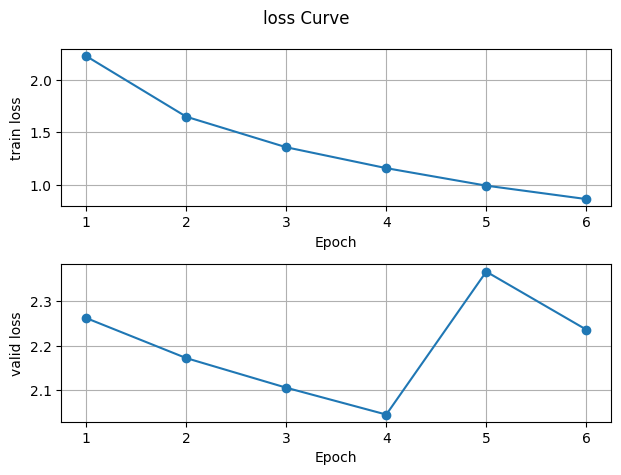

In [27]:
# 결과 시각화

plot_loss_curve(loss_history, metric="loss", overlap=False)

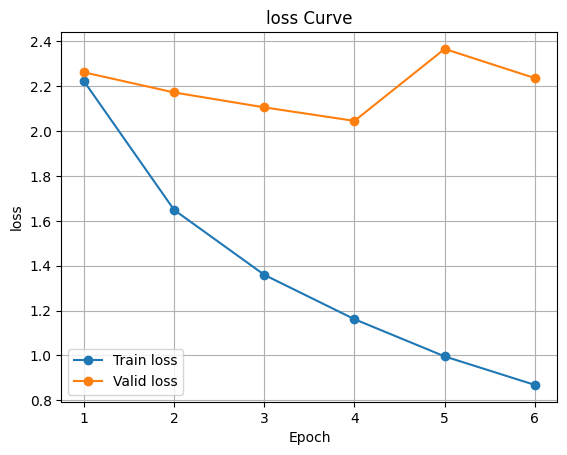

In [28]:
plot_loss_curve(loss_history, metric="loss", overlap=True)

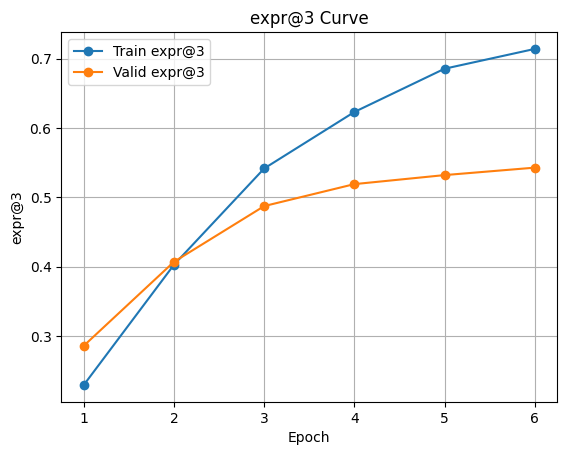

In [29]:
plot_loss_curve(loss_history, metric="expr@3", overlap=True)

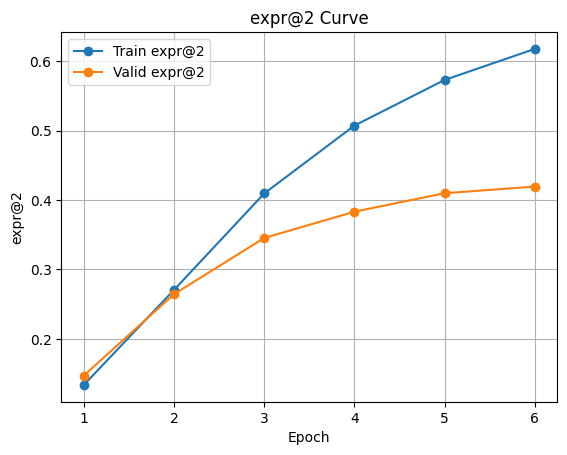

In [30]:
plot_loss_curve(loss_history, metric="expr@2", overlap=True)

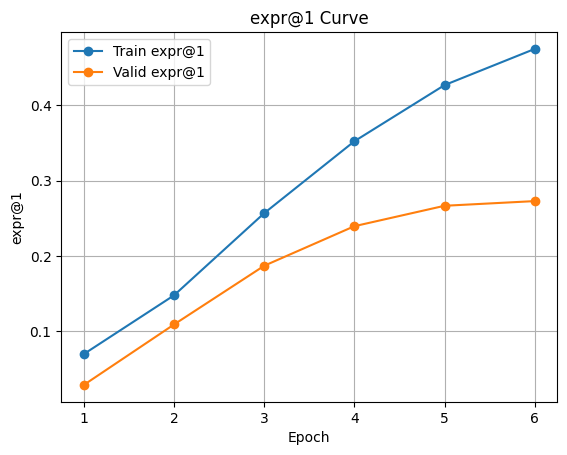

In [31]:
plot_loss_curve(loss_history, metric="expr@1", overlap=True)

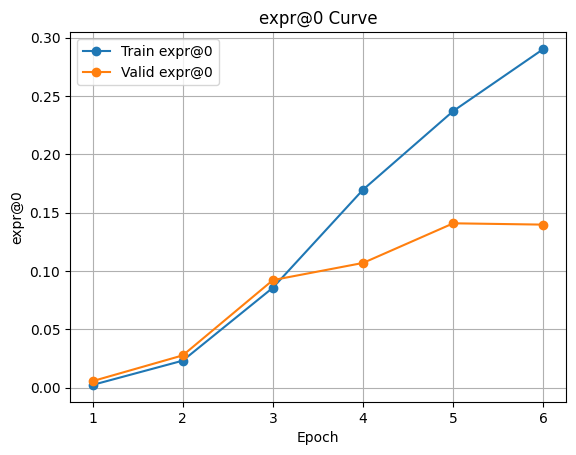

In [32]:
plot_loss_curve(loss_history, metric="expr@0", overlap=True)

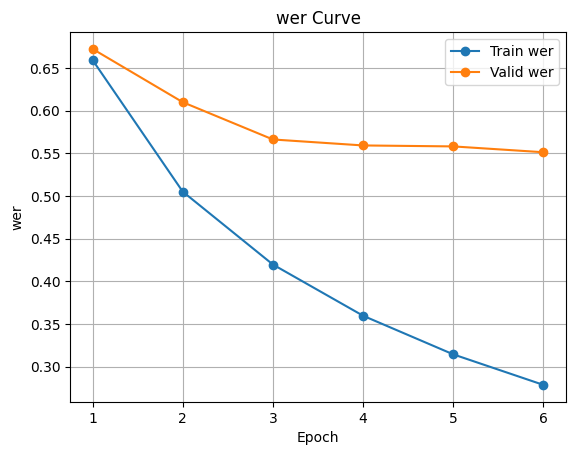

In [33]:
plot_loss_curve(loss_history, metric="wer", overlap=True)

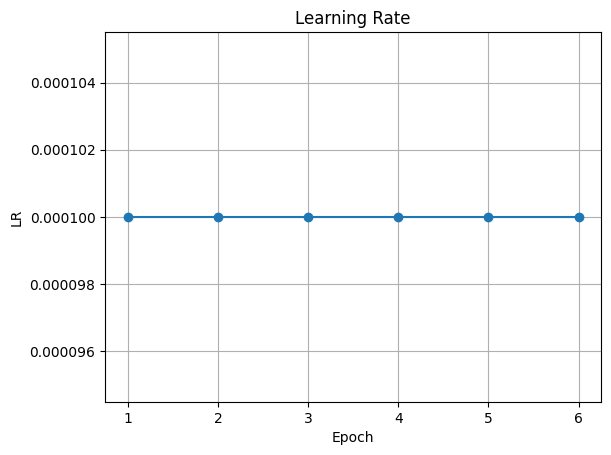

In [34]:
train = loss_history["Train"]

epochs = []
lr = []
for i, history in enumerate(train):
    lr_list = history["lr"]
    epochs.append(i+1)
    lr.append(lr_list[0])

plt.plot(epochs, lr, marker='o')
plt.xlabel("Epoch")
plt.ylabel("LR")
plt.grid(True)
plt.title("Learning Rate")
plt.show()

# Test

In [35]:
# 현재 캐글 노트북에서는 inference 시 logits가 아니라 바로 예측된 값을 내놓으므로 loss 계산은 따로하지 않도록 test함수 약간 수정해서 사용

def test(model, test_loader, criterion, device="cuda"):

    eos_idx = CFG["eos_idx"]
    model.eval()

    total_expr_0, total_expr_1, total_expr_2, total_expr_3 = 0.0, 0.0, 0.0, 0.0
    total_wer = 0.0
    num_batches = 0

    loop = tqdm(test_loader, leave=True)

    for i, batch in enumerate(loop):
        loop.set_description(f"[Test] batch:{i}/{len(test_loader)}")

        imgs = batch["image"].to(device)
        labels = batch["formula"].to(device)

        pred_tokens = model.generate(imgs, MAX_LEN)  # sos제외, eos 포함
        labels = labels[:, 1:]                       # sos제외, eos 포함

        expr_0 = float(exprate_k(preds=pred_tokens, targets=labels, k=0, eos_idx=eos_idx))
        expr_1 = float(exprate_k(preds=pred_tokens, targets=labels, k=1, eos_idx=eos_idx))
        expr_2 = float(exprate_k(preds=pred_tokens, targets=labels, k=2, eos_idx=eos_idx))
        expr_3 = float(exprate_k(preds=pred_tokens, targets=labels, k=3, eos_idx=eos_idx))
        wer = float(WER(preds=pred_tokens, targets=labels, eos_idx=eos_idx))

        total_expr_0 += expr_0
        total_expr_1 += expr_1
        total_expr_2 += expr_2
        total_expr_3 += expr_3
        total_wer += wer
        num_batches += 1

        loop.set_postfix(expr0=expr_0, expr1=expr_1, expr2=expr_2, expr3=expr_3, wer=wer)

    avg_expr_0 = total_expr_0 / num_batches
    avg_expr_1 = total_expr_1 / num_batches
    avg_expr_2 = total_expr_2 / num_batches
    avg_expr_3 = total_expr_3 / num_batches
    avg_wer = total_wer / num_batches

    return avg_expr_0, avg_expr_1, avg_expr_2, avg_expr_3, avg_wer

In [36]:
# best_model.pth 가져오기

import math

VOCAB_SIZE = CFG["model"]["vocab_size"]
FEAT_DIM   = CFG["model"]["decoder_hidden_dim"]
EMB_DIM    = CFG["model"]["encoder_emb_dim"]
EPOCHS     = CFG["training"]["epochs"]
BATCH_SIZE = CFG["training"]["batch_size"]
PAD_IDX    = CFG["pad_idx"]

MAX_LEN = 100

criterion = nn.CrossEntropyLoss(ignore_index=PAD_IDX)


model = HMERNet(1, FEAT_DIM, VOCAB_SIZE, EMB_DIM).to(DEVICE)
model.load_state_dict(torch.load(CFG["paths"]["best_ckpt"])["model"])

<All keys matched successfully>

In [37]:
# 테스트 및 테스트 결과 구글스프레드시트에 저장

from tqdm import tqdm

test_loaders = [crohme_testloader_2014, crohme_testloader_2016, crohme_testloader_2019,
                cropme_testloader_2014, cropme_testloader_2016, cropme_testloader_2019,
                im2latex_hme_testloader, im2latex_pme_testloader]

test_dataset_names = ["CROHME_2014", "CROHME_2016", "CROHME_2019", "CROPME_2014", "CROPME_2016", "CROPME_2019", "IM2LATEX_HME", "IM2LATEX_PME"]

val_dict = {"expr@0": [],
            "expr@1": [],
            "expr@2": [],
            "expr@3": [],
            "wer": []}

for i, test_loader in enumerate(test_loaders):
    test_dataset_name = test_dataset_names[i]
    print(test_dataset_name)

    expr0, expr1, expr2, expr3, wer = test(model, test_loader, criterion)

    val_dict["expr@0"].append(expr0)
    val_dict["expr@1"].append(expr1)
    val_dict["expr@2"].append(expr2)
    val_dict["expr@3"].append(expr3)
    val_dict["wer"].append(wer)


save_test_result(CFG["experiment_name"], val_dict)

CROHME_2014


[Test] batch:985/986: 100%|██████████| 986/986 [06:54<00:00,  2.38it/s, expr0=0, expr1=0, expr2=0, expr3=0, wer=0.926]


CROHME_2016


[Test] batch:1146/1147: 100%|██████████| 1147/1147 [08:08<00:00,  2.35it/s, expr0=0, expr1=0, expr2=0, expr3=0, wer=0.903]


CROHME_2019


...

[Test] batch:1198/1199: 100%|██████████| 1199/1199 [09:19<00:00,  2.14it/s, expr0=0, expr1=0, expr2=0, expr3=0, wer=0.978]


IM2LATEX_HME


[Test] batch:945/946: 100%|██████████| 946/946 [05:40<00:00,  2.78it/s, expr0=0, expr1=0, expr2=0, expr3=0, wer=0.97]


IM2LATEX_PME


[Test] batch:945/946: 100%|██████████| 946/946 [05:13<00:00,  3.02it/s, expr0=0, expr1=0, expr2=0, expr3=0, wer=0.939]


# Prediction 샘플 시각화

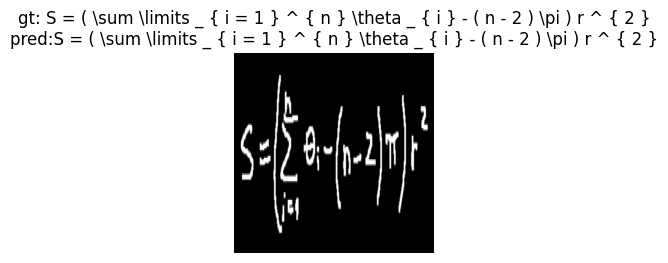

In [55]:
import numpy as np

batch = next(iter(trainloader))
images = batch['image'].to(DEVICE)
labels = batch['formula'].to(DEVICE)
y_hats = model.generate(images, max_len=100)
#y_hats = torch.argmax(y_hats, axis=-1)
plot_dataset(images, labels, grid_width=1, grid_height=1, figure_width=1, figure_height=1, y_hats=y_hats, vocab=vocab)

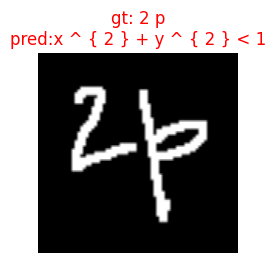

In [41]:
import numpy as np

batch = next(iter(crohme_testloader_2014))
images = batch['image'].to(DEVICE)
labels = batch['formula'].to(DEVICE)
y_hats = model.generate(images, max_len=150)
#y_hats = torch.argmax(y_hats, axis=-1)
plot_dataset(images, labels, grid_width=1, grid_height=1, figure_width=1, figure_height=1, y_hats=y_hats, vocab=vocab)

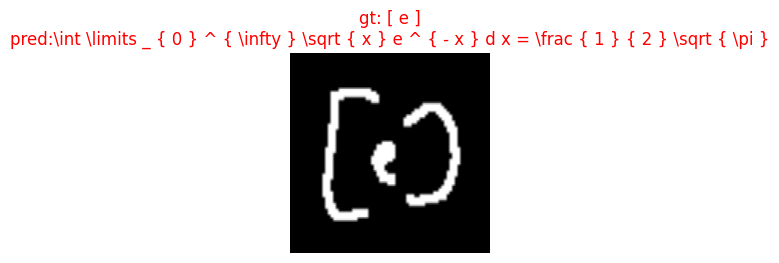

In [42]:
import numpy as np

batch = next(iter(crohme_testloader_2016))
images = batch['image'].to(DEVICE)
labels = batch['formula'].to(DEVICE)
y_hats = model.generate(images, max_len=150)
#y_hats = torch.argmax(y_hats, axis=-1)
plot_dataset(images, labels, grid_width=1, grid_height=1, figure_width=1, figure_height=1, y_hats=y_hats, vocab=vocab)

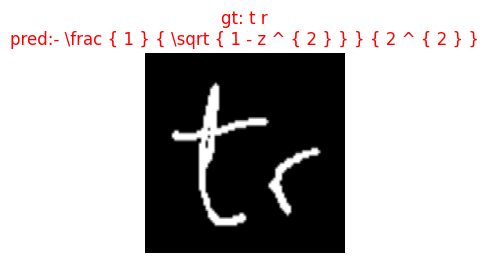

In [43]:
import numpy as np

batch = next(iter(crohme_testloader_2019))
images = batch['image'].to(DEVICE)
labels = batch['formula'].to(DEVICE)
y_hats = model.generate(images, max_len=150)
#y_hats = torch.argmax(y_hats, axis=-1)
plot_dataset(images, labels, grid_width=1, grid_height=1, figure_width=1, figure_height=1, y_hats=y_hats, vocab=vocab)

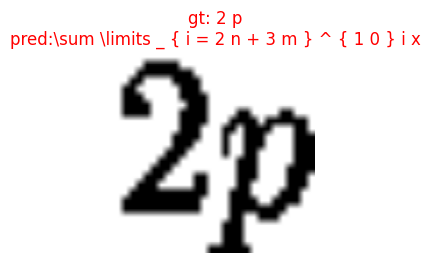

In [44]:
import numpy as np

batch = next(iter(cropme_testloader_2014))
images = batch['image'].to(DEVICE)
labels = batch['formula'].to(DEVICE)
y_hats = model.generate(images, max_len=150)
#y_hats = torch.argmax(y_hats, axis=-1)
plot_dataset(images, labels, grid_width=1, grid_height=1, figure_width=1, figure_height=1, y_hats=y_hats, vocab=vocab)

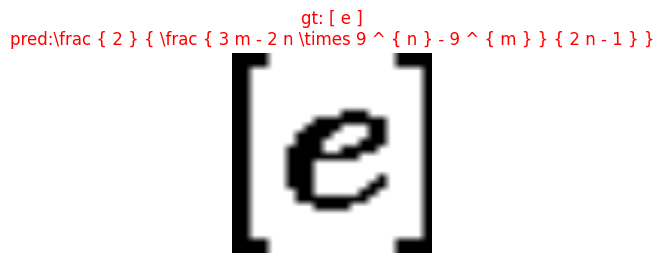

In [45]:
import numpy as np

batch = next(iter(cropme_testloader_2016))
images = batch['image'].to(DEVICE)
labels = batch['formula'].to(DEVICE)
y_hats = model.generate(images, max_len=150)
#y_hats = torch.argmax(y_hats, axis=-1)
plot_dataset(images, labels, grid_width=1, grid_height=1, figure_width=1, figure_height=1, y_hats=y_hats, vocab=vocab)

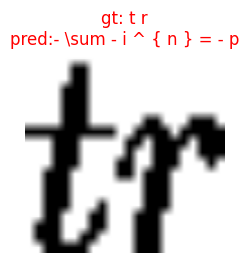

In [46]:
import numpy as np

batch = next(iter(cropme_testloader_2019))
images = batch['image'].to(DEVICE)
labels = batch['formula'].to(DEVICE)
y_hats = model.generate(images, max_len=150)
#y_hats = torch.argmax(y_hats, axis=-1)
plot_dataset(images, labels, grid_width=1, grid_height=1, figure_width=1, figure_height=1, y_hats=y_hats, vocab=vocab)

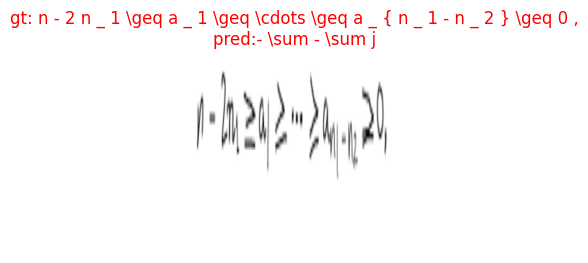

In [47]:
import numpy as np

batch = next(iter(im2latex_hme_testloader))
images = batch['image'].to(DEVICE)
labels = batch['formula'].to(DEVICE)
y_hats = model.generate(images, max_len=150)
#y_hats = torch.argmax(y_hats, axis=-1)
plot_dataset(images, labels, grid_width=1, grid_height=1, figure_width=1, figure_height=1, y_hats=y_hats, vocab=vocab)

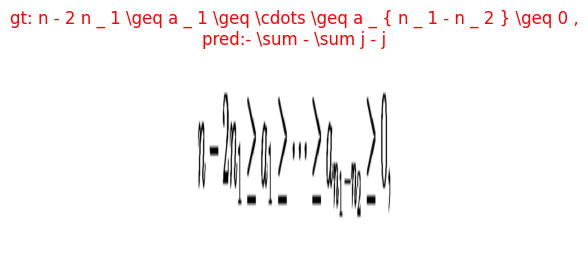

In [48]:
import numpy as np

batch = next(iter(im2latex_pme_testloader))
images = batch['image'].to(DEVICE)
labels = batch['formula'].to(DEVICE)
y_hats = model.generate(images, max_len=150)
#y_hats = torch.argmax(y_hats, axis=-1)
plot_dataset(images, labels, grid_width=1, grid_height=1, figure_width=1, figure_height=1, y_hats=y_hats, vocab=vocab)